In [1]:
import polars as pl
import polars.selectors as cs
import json
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df_etn_native_bfgs_raw = pl.read_csv("results_etn_native_bfgs.csv")
df_etn_scipy_bfgs_raw = pl.read_csv("results_etn_scipy_bfgs.csv")

df_etn_my_sgd = pl.read_csv("results_etn_my_sgd.csv")
df_etn_my_momentum = pl.read_csv("results_etn_my_momentum.csv")
df_etn_my_adam = pl.read_csv("results_etn_my_adam.csv")
df_etn_my_muon_pad_sqrt = pl.read_csv("results_etn_my_muon_pad_sqrt.csv")
df_etn_my_muon_factorization = pl.read_csv("results_etn_my_muon_factorization.csv")

df_etn_native_bfgs = (
    df_etn_native_bfgs_raw
    .rename({
        "train_energy_atom_rmse": "train_epa_rmse",
        "val_energy_atom_rmse": "val_epa_rmse",
    })
    .select([
        "pot_num",
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
    ])
)

df_etn_scipy_bfgs = (
    df_etn_scipy_bfgs_raw
    .rename({
        "train_energy_atom_rmse": "train_epa_rmse",
        "val_energy_atom_rmse": "val_epa_rmse",
    })
    .with_columns(pl.col("nit").alias("steps"))
    .select([
        "pot_num",
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
        "steps",
        "success",
        "final_loss",
    ])
)

df_baseline_bfgs = df_etn_native_bfgs


In [3]:
def without_history(df):
    cols = [c for c in ["losses", "grad_norms", "lrs"] if c in df.columns]
    return df.drop(cols)


def show_mean_std(df):
    if df is None or df.height == 0:
        print("Нет строк с результатами")
        display(df)
        return

    numeric = df.select(cs.numeric())
    cols = [c for c in numeric.columns if c != "pot_num"]

    print("Mean")
    display(numeric.select(cols).mean())
    print("Std")
    display(numeric.select(cols).std())


def compare_ensemble_stats_long(
    df1: pl.DataFrame, name1: str, df2: pl.DataFrame, name2: str
):
    m1 = df1.select(cs.numeric())
    m2 = df2.select(cs.numeric())

    common = [c for c in m1.columns if c in m2.columns]
    common = [c for c in common if c != "pot_num"]

    mean1 = m1.select(common).select(pl.all().mean()).row(0)
    mean2 = m2.select(common).select(pl.all().mean()).row(0)

    std1 = m1.select(common).select(pl.all().std()).row(0)
    std2 = m2.select(common).select(pl.all().std()).row(0)

    mean_df = pl.DataFrame(
        {
            "metric": common,
            "stat": ["mean"] * len(common),
            name1: list(mean1),
            name2: list(mean2),
        }
    )

    std_df = pl.DataFrame(
        {
            "metric": common,
            "stat": ["std"] * len(common),
            name1: list(std1),
            name2: list(std2),
        }
    )

    return mean_df, std_df


def mean_loss_history(df):
    histories = [json.loads(x) for x in df["losses"].to_list()]
    min_len = min(len(x) for x in histories)
    histories = np.array([x[:min_len] for x in histories])
    return histories.mean(axis=0)


def plot_loss_history(df, title):
    if "losses" not in df.columns:
        print("Для этого метода нет loss history в CSV")
        return

    loss_history = mean_loss_history(df)
    iters = np.arange(1, len(loss_history) + 1)

    plt.figure(figsize=(12, 5))
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.plot(iters, loss_history)
    plt.tight_layout()
    plt.show()


def compare_with_baseline(df, name):
    compare_mean, compare_std = compare_ensemble_stats_long(
        df_baseline_bfgs,
        "baseline BFGS",
        df,
        name,
    )
    display(compare_mean)
    display(compare_std)


### Task 6 results

#### Baseline: native BFGS

In [4]:
display(df_etn_native_bfgs)
show_mean_std(df_etn_native_bfgs)
plot_loss_history(df_etn_native_bfgs, "Loss history native BFGS")


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time
i64,f64,f64,f64,f64,f64
1,0.417334,0.51517,0.476876,0.523471,198.23105
2,0.417334,0.51517,0.476876,0.523471,125.346626
3,0.417334,0.51517,0.476876,0.523471,207.082095
4,0.417334,0.51517,0.476876,0.523471,132.760313
5,0.417334,0.51517,0.476876,0.523471,184.632153


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time
f64,f64,f64,f64,f64
0.417334,0.51517,0.476876,0.523471,169.610447


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time
f64,f64,f64,f64,f64
6.2660e-11,3.0352e-10,4.2085e-10,2.7589e-10,37.967529


Для этого метода нет loss history в CSV


Baseline — это обычный BFGS из `mlip_4.Trainer`. Дальше все методы сравниваются именно с ним.

#### SGD

pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,9.969785,0.90027,9.957446,0.887658,257.131469,500,99,163278.113744
2,9.984828,0.900048,9.967085,0.887342,258.376461,500,99,157015.867311
3,9.87369,0.900009,9.853311,0.887304,258.661443,500,99,157982.057858
4,9.940347,0.90032,9.930998,0.887652,306.922408,500,99,151845.216632
5,9.895822,0.899952,9.886233,0.887345,476.446698,500,99,128946.21821


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
9.932894,0.90012,9.919015,0.88746,311.507696,500.0,99.0,151813.494751


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.047416,0.000164,0.048278,0.000179,94.60223,0.0,0.0,13411.438051


metric,stat,baseline BFGS,SGD ETN
str,str,f64,f64
"""train_epa_rmse""","""mean""",0.417334,9.932894
"""train_forces_rmse""","""mean""",0.51517,0.90012
"""val_epa_rmse""","""mean""",0.476876,9.919015
"""val_forces_rmse""","""mean""",0.523471,0.88746
"""train_time""","""mean""",169.610447,311.507696


metric,stat,baseline BFGS,SGD ETN
str,str,f64,f64
"""train_epa_rmse""","""std""",6.2660e-11,0.047416
"""train_forces_rmse""","""std""",3.0352e-10,0.000164
"""val_epa_rmse""","""std""",4.2085e-10,0.048278
"""val_forces_rmse""","""std""",2.7589e-10,0.000179
"""train_time""","""std""",37.967529,94.60223


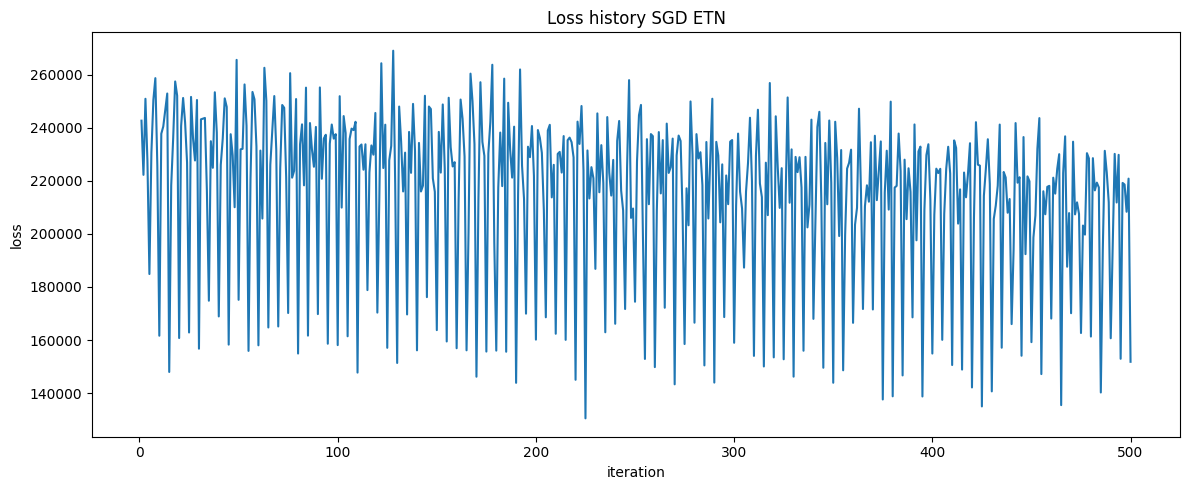

In [5]:
display(without_history(df_etn_my_sgd))
show_mean_std(df_etn_my_sgd)
compare_with_baseline(df_etn_my_sgd, "SGD ETN")
plot_loss_history(df_etn_my_sgd, "Loss history SGD ETN")


#### Momentum

pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,8.907206,0.900252,8.90264,0.887636,782.393193,1500,299,94737.534001
2,8.921663,0.899991,8.911634,0.887289,773.814399,1500,299,109883.260255
3,8.811069,0.899852,8.79867,0.887164,780.90219,1500,299,93738.753211
4,8.877016,0.899904,8.875342,0.887242,775.428938,1500,299,173679.891724
5,8.832978,0.899897,8.831071,0.887305,788.204394,1500,299,132184.555553


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
8.869986,0.899979,8.863871,0.887327,780.148623,1500.0,299.0,120844.798949


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.047292,0.000161,0.04807,0.000181,5.764096,0.0,0.0,33378.958333


metric,stat,baseline BFGS,Momentum ETN
str,str,f64,f64
"""train_epa_rmse""","""mean""",0.417334,8.869986
"""train_forces_rmse""","""mean""",0.51517,0.899979
"""val_epa_rmse""","""mean""",0.476876,8.863871
"""val_forces_rmse""","""mean""",0.523471,0.887327
"""train_time""","""mean""",169.610447,780.148623


metric,stat,baseline BFGS,Momentum ETN
str,str,f64,f64
"""train_epa_rmse""","""std""",6.2660e-11,0.047292
"""train_forces_rmse""","""std""",3.0352e-10,0.000161
"""val_epa_rmse""","""std""",4.2085e-10,0.04807
"""val_forces_rmse""","""std""",2.7589e-10,0.000181
"""train_time""","""std""",37.967529,5.764096


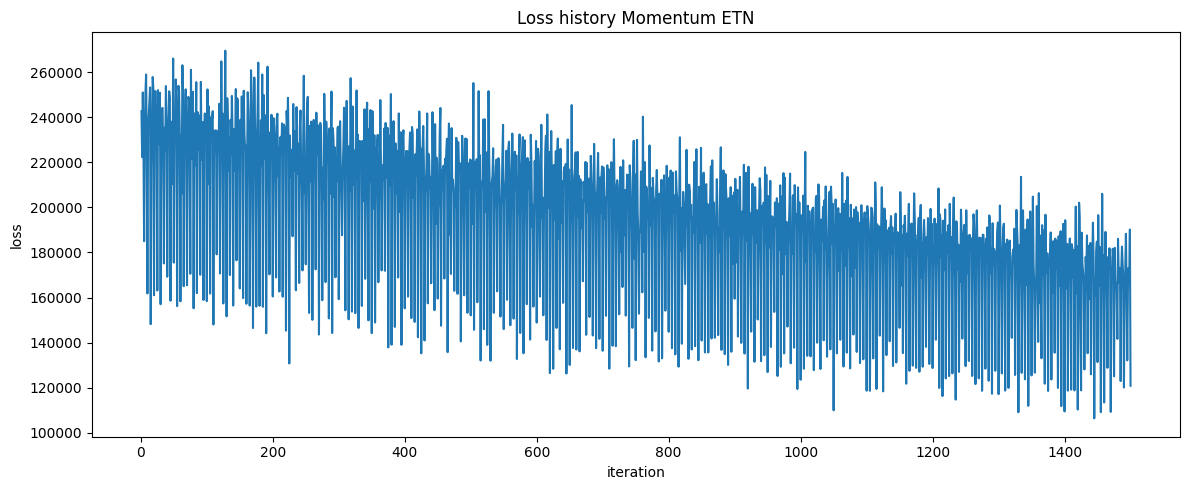

In [6]:
display(without_history(df_etn_my_momentum))
show_mean_std(df_etn_my_momentum)
compare_with_baseline(df_etn_my_momentum, "Momentum ETN")
plot_loss_history(df_etn_my_momentum, "Loss history Momentum ETN")


#### Adam

pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,1.111653,1.125941,1.250134,1.120334,808.468121,1500,299,176.938107
2,1.120429,1.118879,1.255102,1.112381,798.64842,1500,299,132.062823
3,1.0952,1.122924,1.225381,1.117599,795.232207,1500,299,197.434558
4,1.10776,1.115729,1.242356,1.110489,779.7367,1500,299,67.007006
5,1.105231,1.144333,1.243938,1.13894,776.207039,1500,299,151.954358


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
1.108055,1.125561,1.243382,1.119949,791.658498,1500.0,299.0,145.079371


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.009211,0.011189,0.011273,0.011326,13.463569,0.0,0.0,50.169799


metric,stat,baseline BFGS,Adam ETN
str,str,f64,f64
"""train_epa_rmse""","""mean""",0.417334,1.108055
"""train_forces_rmse""","""mean""",0.51517,1.125561
"""val_epa_rmse""","""mean""",0.476876,1.243382
"""val_forces_rmse""","""mean""",0.523471,1.119949
"""train_time""","""mean""",169.610447,791.658498


metric,stat,baseline BFGS,Adam ETN
str,str,f64,f64
"""train_epa_rmse""","""std""",6.2660e-11,0.009211
"""train_forces_rmse""","""std""",3.0352e-10,0.011189
"""val_epa_rmse""","""std""",4.2085e-10,0.011273
"""val_forces_rmse""","""std""",2.7589e-10,0.011326
"""train_time""","""std""",37.967529,13.463569


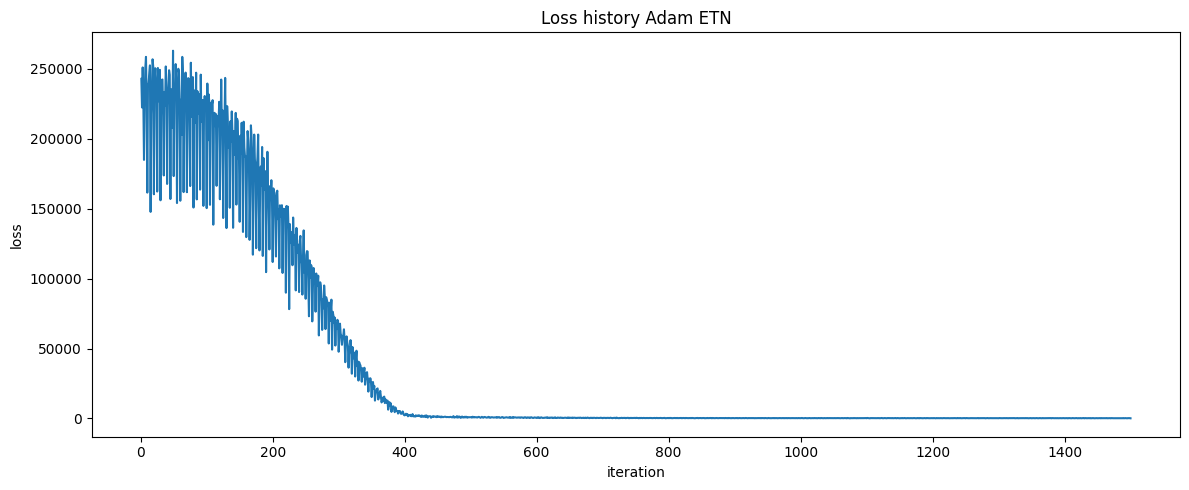

In [7]:
display(without_history(df_etn_my_adam))
show_mean_std(df_etn_my_adam)
compare_with_baseline(df_etn_my_adam, "Adam ETN")
plot_loss_history(df_etn_my_adam, "Loss history Adam ETN")


#### Muon pad sqrt

pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,5.094459,2.3977,5.271212,2.338693,773.119829,1500,299,26648.642381
2,5.713422,2.726693,5.915482,2.687306,773.106387,1500,299,37504.649674
3,5.191114,2.45944,5.365889,2.432965,773.953146,1500,299,28027.140522
4,6.677124,2.032799,6.836209,1.978942,772.453606,1500,299,89897.605951
5,5.834948,2.341561,6.00141,2.299103,771.679148,1500,299,47477.469637


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
5.702214,2.391638,5.87804,2.347402,772.862423,1500.0,299.0,45911.101633


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.632215,0.249083,0.625549,0.255454,0.848929,0.0,0.0,25975.050081


metric,stat,baseline BFGS,Muon pad sqrt ETN
str,str,f64,f64
"""train_epa_rmse""","""mean""",0.417334,5.702214
"""train_forces_rmse""","""mean""",0.51517,2.391638
"""val_epa_rmse""","""mean""",0.476876,5.87804
"""val_forces_rmse""","""mean""",0.523471,2.347402
"""train_time""","""mean""",169.610447,772.862423


metric,stat,baseline BFGS,Muon pad sqrt ETN
str,str,f64,f64
"""train_epa_rmse""","""std""",6.2660e-11,0.632215
"""train_forces_rmse""","""std""",3.0352e-10,0.249083
"""val_epa_rmse""","""std""",4.2085e-10,0.625549
"""val_forces_rmse""","""std""",2.7589e-10,0.255454
"""train_time""","""std""",37.967529,0.848929


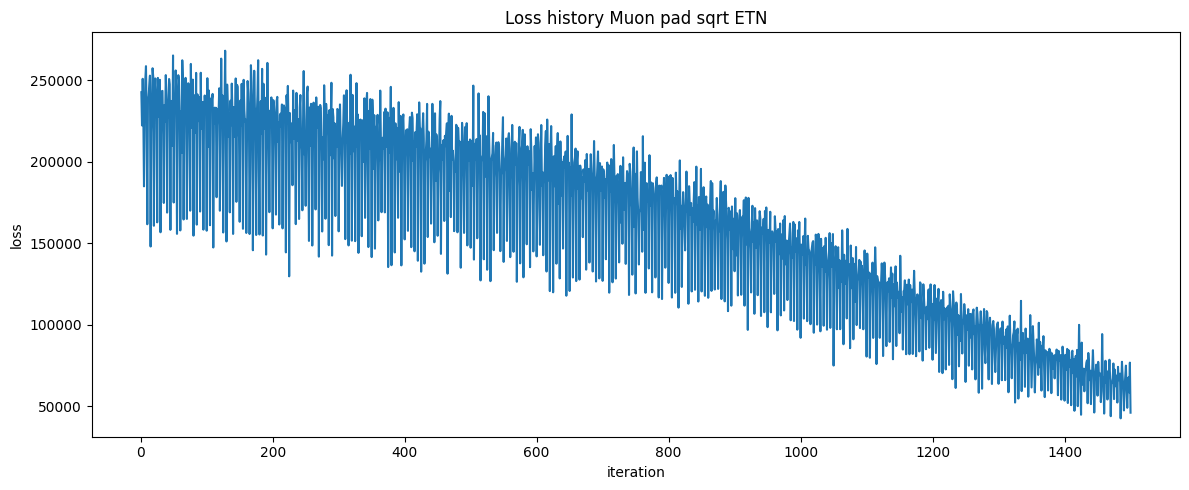

In [8]:
display(without_history(df_etn_my_muon_pad_sqrt))
show_mean_std(df_etn_my_muon_pad_sqrt)
compare_with_baseline(df_etn_my_muon_pad_sqrt, "Muon pad sqrt ETN")
plot_loss_history(df_etn_my_muon_pad_sqrt, "Loss history Muon pad sqrt ETN")


#### Muon factorization

pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,6.307622,1.164111,6.543667,1.091389,781.516469,1500,299,44580.959077
2,6.900645,0.994778,7.100153,0.955892,797.663853,1500,299,58004.847683
3,6.464503,1.282563,6.660869,1.232594,797.212688,1500,299,41100.430007
4,7.474632,1.057854,7.681911,1.005119,795.440067,1500,299,101683.752591
5,6.900159,1.103995,7.163566,1.036183,778.954405,1500,299,65469.726253


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
6.809512,1.12066,7.030033,1.064235,790.157496,1500.0,299.0,62167.943122


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,epochs,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.455476,0.109737,0.452915,0.106186,9.140614,0.0,0.0,24201.624171


metric,stat,baseline BFGS,Muon factorization ETN
str,str,f64,f64
"""train_epa_rmse""","""mean""",0.417334,6.809512
"""train_forces_rmse""","""mean""",0.51517,1.12066
"""val_epa_rmse""","""mean""",0.476876,7.030033
"""val_forces_rmse""","""mean""",0.523471,1.064235
"""train_time""","""mean""",169.610447,790.157496


metric,stat,baseline BFGS,Muon factorization ETN
str,str,f64,f64
"""train_epa_rmse""","""std""",6.2660e-11,0.455476
"""train_forces_rmse""","""std""",3.0352e-10,0.109737
"""val_epa_rmse""","""std""",4.2085e-10,0.452915
"""val_forces_rmse""","""std""",2.7589e-10,0.106186
"""train_time""","""std""",37.967529,9.140614


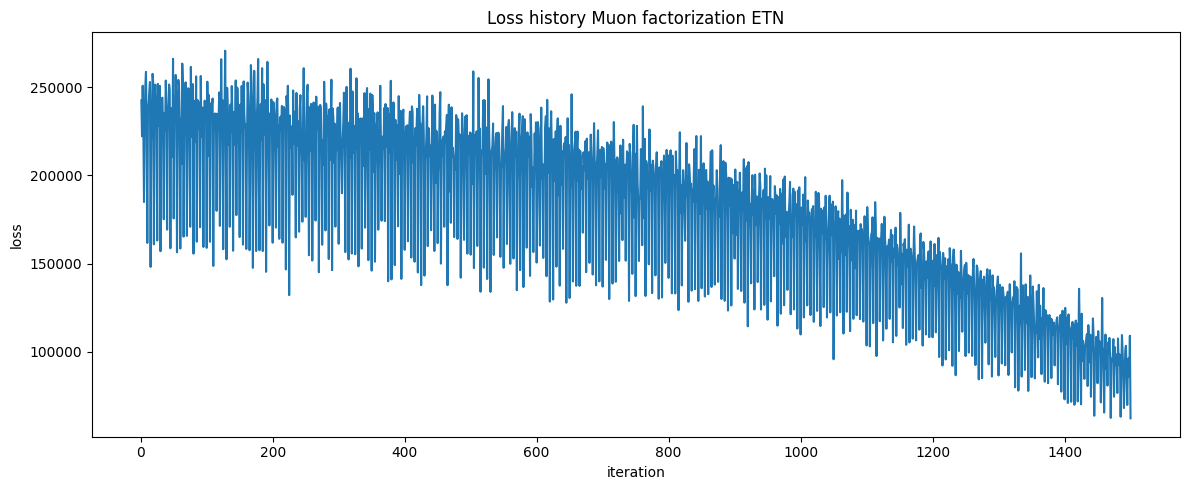

In [9]:
display(without_history(df_etn_my_muon_factorization))
show_mean_std(df_etn_my_muon_factorization)
compare_with_baseline(df_etn_my_muon_factorization, "Muon factorization ETN")
plot_loss_history(df_etn_my_muon_factorization, "Loss history Muon factorization ETN")


#### SciPy BFGS

In [10]:
display(without_history(df_etn_scipy_bfgs))
show_mean_std(df_etn_scipy_bfgs)
compare_with_baseline(df_etn_scipy_bfgs, "SciPy BFGS ETN")
plot_loss_history(df_etn_scipy_bfgs, "Loss history SciPy BFGS ETN")


pot_num,train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,success,final_loss
i64,f64,f64,f64,f64,f64,i64,i64,f64
1,0.359549,0.516251,0.499952,0.529053,258.882114,245,0,188.867473
2,0.547667,0.558612,0.571628,0.57436,319.135586,152,0,188.867473
3,0.359549,0.516251,0.499952,0.529053,208.544352,167,0,188.867473
4,0.359549,0.516251,0.499952,0.529053,169.851839,195,0,188.867473
5,0.359549,0.516251,0.499952,0.529053,268.183511,182,0,188.867473


Mean


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,success,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.397173,0.524723,0.514287,0.538115,244.91948,188.2,0.0,188.867473


Std


train_epa_rmse,train_forces_rmse,val_epa_rmse,val_forces_rmse,train_time,steps,success,final_loss
f64,f64,f64,f64,f64,f64,f64,f64
0.084129,0.018944,0.032054,0.020262,57.451069,35.604775,0.0,1.3701e-12


metric,stat,baseline BFGS,SciPy BFGS ETN
str,str,f64,f64
"""train_epa_rmse""","""mean""",0.417334,0.397173
"""train_forces_rmse""","""mean""",0.51517,0.524723
"""val_epa_rmse""","""mean""",0.476876,0.514287
"""val_forces_rmse""","""mean""",0.523471,0.538115
"""train_time""","""mean""",169.610447,244.91948


metric,stat,baseline BFGS,SciPy BFGS ETN
str,str,f64,f64
"""train_epa_rmse""","""std""",6.2660e-11,0.084129
"""train_forces_rmse""","""std""",3.0352e-10,0.018944
"""val_epa_rmse""","""std""",4.2085e-10,0.032054
"""val_forces_rmse""","""std""",2.7589e-10,0.020262
"""train_time""","""std""",37.967529,57.451069


Для этого метода нет loss history в CSV


#### Общее сравнение всех методов

In [11]:
def method_summary(method_name, df):
    numeric_cols = [
        "train_epa_rmse",
        "train_forces_rmse",
        "val_epa_rmse",
        "val_forces_rmse",
        "train_time",
        "steps",
        "epochs",
        "success",
        "final_loss",
    ]
    data = {"method": method_name}

    for col in numeric_cols:
        if col in df.columns:
            data[f"{col}_mean"] = df[col].mean()
            data[f"{col}_std"] = df[col].std()

    return data


def methods_summary(methods):
    return pl.DataFrame([method_summary(name, df) for name, df in methods])


def plot_methods_comparison(summary, title):
    methods = summary["method"].to_list()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title)

    axes[0].bar(methods, summary["val_epa_rmse_mean"].to_list())
    axes[0].set_title("val_epa_rmse")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(methods, summary["val_forces_rmse_mean"].to_list())
    axes[1].set_title("val_forces_rmse")
    axes[1].set_ylabel("RMSE")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_methods_loss_history(methods, title):
    plt.figure(figsize=(12, 6))
    plt.title(title)
    plt.xlabel("iteration")
    plt.ylabel("loss")

    plotted = False
    for name, df in methods:
        if df is None or df.height == 0 or "losses" not in df.columns:
            print(f"Для {name} нет loss history в CSV")
            continue

        loss_history = mean_loss_history(df)
        iters = np.arange(1, len(loss_history) + 1)
        plt.plot(iters, loss_history, label=name)
        plotted = True

    if plotted:
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        plt.close()
        print("Нет методов с сохраненной историей loss")


method,train_epa_rmse_mean,train_epa_rmse_std,train_forces_rmse_mean,train_forces_rmse_std,val_epa_rmse_mean,val_epa_rmse_std,val_forces_rmse_mean,val_forces_rmse_std,train_time_mean,train_time_std,steps_mean,steps_std,success_mean,success_std,final_loss_mean,final_loss_std,epochs_mean,epochs_std
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""native BFGS""",0.417334,6.2660e-11,0.51517,3.0352e-10,0.476876,4.2085e-10,0.523471,2.7589e-10,169.610447,37.967529,null,null,null,null,null,null,null,null
"""SciPy BFGS""",0.397173,0.084129,0.524723,0.018944,0.514287,0.032054,0.538115,0.020262,244.91948,57.451069,188.2,35.604775,0.0,0.0,188.867473,1.3701e-12,null,null
"""Adam""",1.108055,0.009211,1.125561,0.011189,1.243382,0.011273,1.119949,0.011326,791.658498,13.463569,1500.0,0.0,null,null,145.079371,50.169799,299.0,0.0
"""Muon pad sqrt""",5.702214,0.632215,2.391638,0.249083,5.87804,0.625549,2.347402,0.255454,772.862423,0.848929,1500.0,0.0,null,null,45911.101633,25975.050081,299.0,0.0
"""Muon factorization""",6.809512,0.455476,1.12066,0.109737,7.030033,0.452915,1.064235,0.106186,790.157496,9.140614,1500.0,0.0,null,null,62167.943122,24201.624171,299.0,0.0
"""Momentum""",8.869986,0.047292,0.899979,0.000161,8.863871,0.04807,0.887327,0.000181,780.148623,5.764096,1500.0,0.0,null,null,120844.798949,33378.958333,299.0,0.0
"""SGD""",9.932894,0.047416,0.90012,0.000164,9.919015,0.048278,0.88746,0.000179,311.507696,94.60223,500.0,0.0,null,null,151813.494751,13411.438051,99.0,0.0


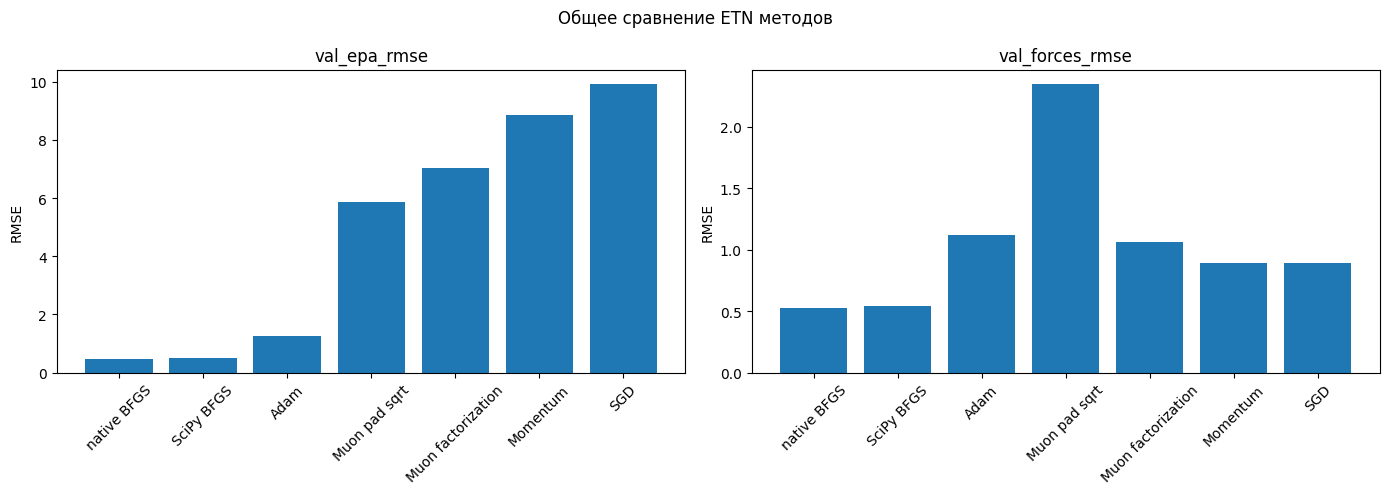

Для native BFGS нет loss history в CSV
Для SciPy BFGS нет loss history в CSV


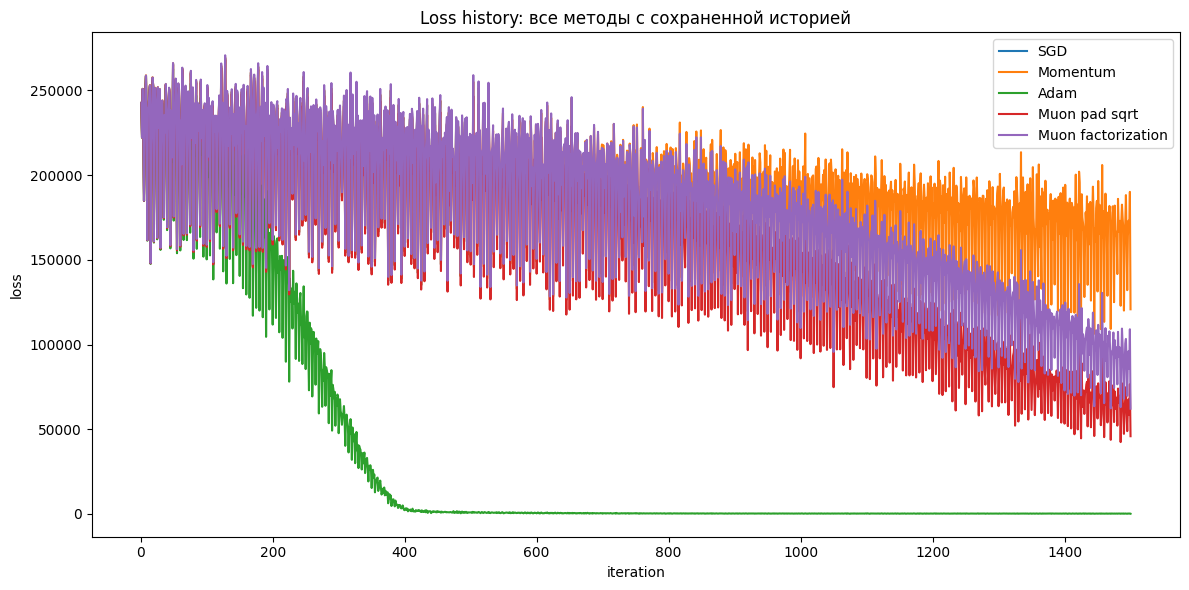

In [12]:
all_methods = [
    ("native BFGS", df_etn_native_bfgs),
    ("SciPy BFGS", df_etn_scipy_bfgs),
    ("SGD", df_etn_my_sgd),
    ("Momentum", df_etn_my_momentum),
    ("Adam", df_etn_my_adam),
    ("Muon pad sqrt", df_etn_my_muon_pad_sqrt),
    ("Muon factorization", df_etn_my_muon_factorization),
]

summary = methods_summary(all_methods).sort("val_epa_rmse_mean")

display(summary)
plot_methods_comparison(summary, "Общее сравнение ETN методов")
plot_methods_loss_history(all_methods, "Loss history: все методы с сохраненной историей")


По итоговой таблице удобнее всего смотреть на `val_epa_rmse_mean` и `val_forces_rmse_mean`. History-график строится только для методов, где история обучения была сохранена в CSV.